# Coupled Model Test

Speedy + Slab Ocean Model

In [1]:
import os
#os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/xtt/projects/jax-gcm
Add Path:  /home/xtt/projects/jax-esm


In [3]:
import numpy as np
import xarray as xr
import pandas as pd

import jcm
import jax_esm
from jax_esm.coupling.coupler import Coupler
from jax_esm.components.base import ComponentConfig
from jax_esm.components.Speedy import Speedy
from jax_esm.components.SlabOceanModel import SlabOceanModel
from jax_esm.components.FluxModel import FluxModel

## Create Boundary File

In [4]:
from pathlib import Path
from jcm.model import get_coords
from jcm.boundaries import boundaries_from_file

# Prepare boundary file
boundary_file = (Path(jax_esm.__file__).parent / "data" / "boundaries_daily.nc").resolve()

if not boundary_file.exists():
    print("Boundary file %s does not exist. Need to produce it." % (str(boundary_file),))
    import subprocess, sys
    interpolation_file = boundary_file.parent / "interpolate.py"
    subprocess.run([sys.executable, str(interpolation_file)], check=True)

if boundary_file.exists():
    print("Boundary file %s exists!" % (str(boundary_file), ) )
else:
    raise Exception("Something went wrong. The daily file is not generated. Please check.")

boundaries = boundaries_from_file(
    boundary_file,
    get_coords().horizontal
)

Boundary file /home/xtt/projects/jax-esm/jax_esm/data/boundaries_daily.nc exists!


## Create Model

Currently, the time steps are not checked to be consistent. Should be checked in the future.

In [5]:
start_dt = pd.Timestamp("2001-01-01")

sim_start_time = 0.0
total_simulation_time  =  5 * 86400.0 # sec
sim_end_time = sim_start_time + total_simulation_time

coupler_time_step      =  86400.0  # sec
coupler_steps          =  int(total_simulation_time / coupler_time_step)

atm_substeps          =  12           # count
atm_save_interval     =  coupler_time_step / atm_substeps # coupler_time_step # sec

ocn_substeps          =  1            # count
ocn_save_interval     = 24 *  3600.0  # sec

flx_substeps          =  1            # count
flx_save_interval     = 24 *  3600.0  # sec

In [6]:
# Coupler Config
config_master = dict(
    total_simulation_time = total_simulation_time,
    time_step = coupler_time_step,
)

# Atmosphere model
config_atm = ComponentConfig(
    name = "atm",
    start_dt = start_dt,
    timestep = coupler_time_step,
    substeps = atm_substeps,
    save_interval = atm_save_interval,
    grid = None,
    params = dict(
        boundaries = boundaries,
    ),
)

model_atm = Speedy(
    config = config_atm,
)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    start_dt = start_dt,
    timestep = coupler_time_step,
    substeps = ocn_substeps,
    save_interval = ocn_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
        relaxation_time = 86400.0 * 60,
        boundaries = boundaries,
        boundary_file = boundary_file,
    ),
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    start_dt = start_dt,
    timestep = coupler_time_step,
    substeps = flx_substeps,
    save_interval = flx_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
        boundaries = boundaries,
        boundary_file = boundary_file,
    ),
)
model_flx = FluxModel(config_flx)

In [7]:
coupler = Coupler(
    config = config_master,
    components = dict(
        flx = model_flx,
        atm = model_atm,
        ocn = model_ocn,
    ), 
)

init_cplstate = coupler.initialize()

Boundary exists. 
Boundary file:  /home/xtt/projects/jax-esm/jax_esm/data/boundaries_daily.nc
fmask_ocn and init_T do share the same mask.


# Plot initial conditions

In [8]:
import xarray as xr

In [9]:
prog_varnames = list(init_cplstate.atm.prog.__dataclass_fields__.keys())

for varname in prog_varnames:
    v = getattr(init_cplstate.atm.prog, varname)
    print(f"Keys in atm.prog = {varname:s} => ", v.shape )
    

Keys in atm.prog = u_wind =>  (8, 96, 48)
Keys in atm.prog = v_wind =>  (8, 96, 48)
Keys in atm.prog = temperature =>  (8, 96, 48)
Keys in atm.prog = specific_humidity =>  (8, 96, 48)
Keys in atm.prog = geopotential =>  (8, 96, 48)
Keys in atm.prog = normalized_surface_pressure =>  (96, 48)


/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2145: UserWarning: The following kwargs were not used by contour: 'extends'
  primitive = ax.contourf(x, y, z, **kwargs)


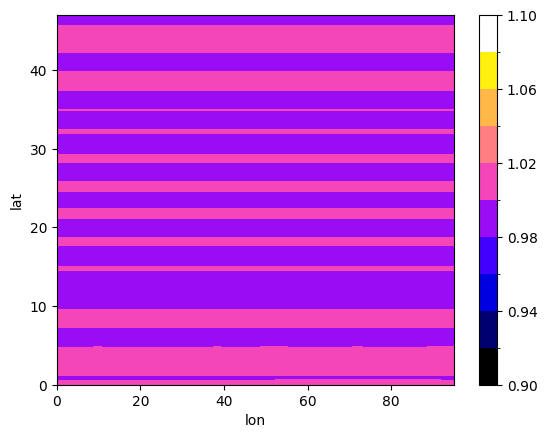

In [10]:
init_nsp = xr.DataArray(
    data = init_cplstate.atm.prog.normalized_surface_pressure,
    dims = ["lon", "lat"],
)
init_nsp.plot.contourf(x='lon', y='lat', cmap="gnuplot2", add_colorbar=True, levels=np.linspace(0.9, 1.1, 11), extends="both")

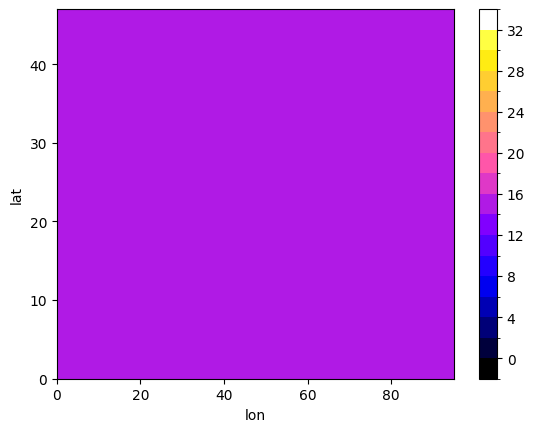

In [11]:
init_temperature = xr.DataArray(
    data = init_cplstate.atm.prog.temperature,
    dims = ["z", "lon", "lat"],
)
(init_temperature-273.15).isel(z=0).plot.contourf(x='lon', y='lat', cmap="gnuplot2", add_colorbar=True, levels=np.arange(-2, 36, 2), extends="both")

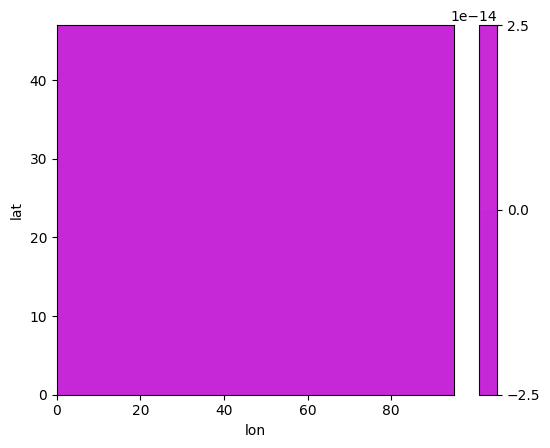

In [12]:
init_u = xr.DataArray(
    data = init_cplstate.atm.prog.u_wind,
    dims = ["z", "lon", "lat"],
)
init_u.isel(z=0).plot.contourf(x='lon', y='lat', cmap="gnuplot2", add_colorbar=True, extends="both")


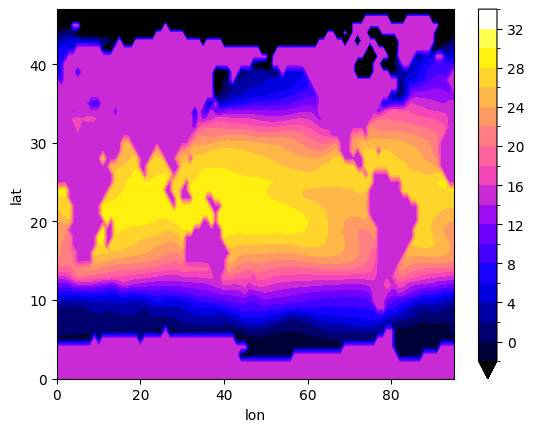

In [13]:
init_SST = xr.DataArray(
    data = init_cplstate.ocn.prog.T,
    dims = ["lon", "lat"],
)

(init_SST-273.15).plot.contourf(x='lon', y='lat', cmap="gnuplot2", add_colorbar=True, levels=np.arange(-2, 36, 2), extends="both")


# Run the Model

You can set `jax_scan = True` to test if `jax.lax.scan` will work.
Currently, it does not because the first input carry and output of the first time step do not have the same shape. `PhysicsData` in `Prediction` is a stacked variable, and its stacked shape is not pre-determined.

When set `jax_scan = False`, use the ad-hoc scan defined in `Coupler.py`.

In [14]:
import numpy as np

final_cpl_state, pred = coupler.run(
    init_cplstate = init_cplstate,
    start_time    = sim_start_time,
    end_time      = sim_end_time,
    timestep      = coupler_time_step,
    save_interval_steps = 1,
    jax_scan = True, 
)

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/scalar_types.py:49: UserWarning: Explicitly requested dtype int64 requested in asarray is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jax.numpy.asarray(x, dtype=self.dtype)


TypeError: scan body function carry input and carry output must have equal types, but they differ:

  * the input carry component cplstate[<flat index 0>][<flat index 1>][<flat index 5>] has type float32[96,48,2] but the corresponding output carry component has type float32[12,96,48,2], so the shapes do not match;

  * the input carry component cplstate[<flat index 1>][<flat index 0>][<flat index 0>] has type float32[8,96,48] but the corresponding output carry component has type float32[12,8,96,48], so the shapes do not match;

  * the input carry component cplstate[<flat index 1>][<flat index 0>][<flat index 1>] has type float32[8,96,48] but the corresponding output carry component has type float32[12,8,96,48], so the shapes do not match;

  * the input carry component cplstate[<flat index 1>][<flat index 0>][<flat index 2>] has type float32[8,96,48] but the corresponding output carry component has type float32[12,8,96,48], so the shapes do not match;

  * the input carry component cp

In [ ]:
print("Convert data to xarray")
ds_dict = coupler.predictions_to_xarray(pred)

# Diagnostics Plots

In [ ]:
import matplotlib.pyplot as plt

## Ocean Model Diagnostics

In [ ]:
ocn_ds = ds_dict["ocn"]

In [ ]:
ocn_ds["mld"].plot(x='lon', y='lat', col="time", col_wrap=3)

In [ ]:

ax = (ocn_ds["T"]-ocn_ds["T"].isel(time=0)).plot.contourf(x='lon', y='lat', col="time", col_wrap=3, cmap="bwr", levels=np.linspace(-1, 1, 21)*2)
plt.suptitle("SST")


In [ ]:
ax = (ocn_ds["time"]/86400).plot(x='time', marker="o", markersize=10)
plt.grid(True)

## Flux Diagnostics

In [ ]:
flx_ds = ds_dict["flx"]

In [ ]:
flx_ds["hfluxn"].isel(layer=0).plot(x='lon', y='lat', col="time", col_wrap=3)

## Verify What Atmosphere Model Sees

In [ ]:
import numpy as np
import jax
from jcm.model import Predictions
import xarray as xr

time_slice = slice(0, None, atm_substeps)

# This function seems to have trouble dealing with stacked data.
pred_ds = ds_dict["atm"]


In [ ]:
pred_ds["u_wind"].isel(level=2, time=time_slice).plot.contourf(x='lon', y='lat', col="time", col_wrap=3, cmap="bwr", levels=np.linspace(-1, 1, 21)*30)

In [ ]:
pred_ds["specific_humidity"].isel(level=0, time=time_slice).plot(x='lon', y='lat', col="time", col_wrap=3)

In [ ]:
pred_ds["surface_flux.tskin"].isel(time=time_slice).plot(x='lon', y='lat', col="time", col_wrap=3)

## Verify the atmosphere sees the same SST as ocean gives

In [ ]:
print("The result should be zero, or very small numbers.")

# Atmosphere see SST a coupled-step late because of the framework
daily_sst_atm = pred_ds["surface_flux.tskin"].isel(time=time_slice).isel(time=slice(1, None, None))
daily_sst_ocn = ocn_ds["T"].isel(time=slice(0, -1, None))

# The time coordniates do not have the same unit. So I drop them for now.
daily_sst_atm = daily_sst_atm.drop_vars("time")
daily_sst_ocn = daily_sst_ocn.drop_vars("time")

SST_diff = daily_sst_atm - daily_sst_ocn 
SST_diff.plot.contourf(x='lon', y='lat', col="time", col_wrap=3, cmap="bwr")